# Unitree G1 Humanoid: Place Apple in Bowl with PPO (V13 - Drop from Above)

This notebook trains a Unitree G1 humanoid robot to place an apple in a bowl using Proximal Policy Optimization (PPO) reinforcement learning with ManiSkill3.

## Key Challenges
- **Action masking**: 25D → 13D by zeroing left arm (right arm only)
- **Staged manipulation**: Reach → Grasp → Place → Release
- **GPU parallelization**: 512 environments running in parallel on GPU

## V12 Changes (Major Fix from V11)
**V11 Problem**: Agent learned to hold apple above bowl but never actually place it.
Success rate = 0% despite high rewards (40+).

**Root Cause**: 
- Success requires apple within 0.05m of bowl center (horizontal) + hand > 0.125m above
- V11 only rewarded being "above" bowl, not "centered + lowered"

**V13 Drop Strategy**:
1. **Above Bowl Position** - relaxed horizontal requirement (within 0.12m)
2. **Optimal Drop Height** - maintain 0.12-0.25m above bowl for reliable drop  
3. **Ready-to-Drop Bonus** - reward being in position AND opening gripper
4. **Release and Fall Detection** - big bonus (2.5) for releasing above bowl
5. **Quick Hand Retreat** - must move up immediately after release to avoid blocking
6. **Anti-Hover Penalty** - prevent holding forever
7. **Direct Success Bonus** - immediate reward (+5.0) when success conditions met

## Setup
- Environment: `UnitreeG1PlaceAppleInBowl-v1`
- Algorithm: PPO with GAE (aligned with ManiSkill3 baseline)
- Total timesteps: 100M
- Parallel envs: 512
- Hardware target: RTX 6000 Ada (48GB)


In [6]:
# Part 1: Setup and Imports
import gymnasium as gym
import mani_skill.envs  # Register ManiSkill environments
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import mediapy as media
from tqdm import tqdm
import time
import os
from typing import Dict, Any, Tuple, Optional
from mani_skill.utils.wrappers.gymnasium import CPUGymWrapper
from mani_skill.vector.wrappers.gymnasium import ManiSkillVectorEnv

# Hardware check
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("WARNING: CUDA not available, training will be slow!")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create output directory
os.makedirs("./results_g1", exist_ok=True)

PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device: NVIDIA RTX 6000 Ada Generation
CUDA memory: 50.87 GB
Using device: cuda


## Part 3: Actor-Critic Network

Architecture:
- Separate critic network: obs_dim → 256 → 256 → 256 → 1
- Separate actor mean network: obs_dim → 256 → 256 → 256 → action_dim
- Learnable log_std initialized to -0.5
- Orthogonal initialization: sqrt(2) for hidden, 0.01*sqrt(2) for actor output, 1.0 for critic output

In [7]:
class ActorCritic(nn.Module):
    def __init__(self, obs_dim: int, action_dim: int):
        super().__init__()

        # Separate critic network: obs -> 256 -> 256 -> 256 -> 1
        self.critic = nn.Sequential(
            nn.Linear(obs_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, 1),
        )

        # Separate actor mean network: obs -> 256 -> 256 -> 256 -> action_dim
        self.actor_mean = nn.Sequential(
            nn.Linear(obs_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, action_dim),
        )

        # Learnable log standard deviation
        self.actor_logstd = nn.Parameter(torch.ones(action_dim) * -0.5)

        # Orthogonal initialization for critic hidden layers: gain sqrt(2)
        for module in self.critic:
            if isinstance(module, nn.Linear):
                nn.init.orthogonal_(module.weight, gain=np.sqrt(2))
                nn.init.constant_(module.bias, 0)
        # Critic output: gain 1.0
        nn.init.orthogonal_(self.critic[-1].weight, gain=1.0)
        nn.init.constant_(self.critic[-1].bias, 0)

        # Orthogonal initialization for actor hidden layers: gain sqrt(2)
        for module in self.actor_mean:
            if isinstance(module, nn.Linear):
                nn.init.orthogonal_(module.weight, gain=np.sqrt(2))
                nn.init.constant_(module.bias, 0)
        # Actor output: gain 0.01 * sqrt(2)
        nn.init.orthogonal_(self.actor_mean[-1].weight, gain=0.01 * np.sqrt(2))
        nn.init.constant_(self.actor_mean[-1].bias, 0)

    def get_action_and_value(self, obs: torch.Tensor, action: Optional[torch.Tensor] = None
                            ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        action_mean = self.actor_mean(obs)
        clamped_logstd = torch.clamp(self.actor_logstd, min=-2.0, max=0.5)
        std = torch.exp(clamped_logstd)
        dist = torch.distributions.Normal(action_mean, std)
        if action is None:
            action = dist.sample()
        log_prob = dist.log_prob(action).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1)
        value = self.critic(obs).squeeze(-1)
        return action, log_prob, entropy, value

    def get_value(self, obs: torch.Tensor) -> torch.Tensor:
        return self.critic(obs).squeeze(-1)

    def get_action_mean(self, obs: torch.Tensor) -> torch.Tensor:
        return self.actor_mean(obs)

# Test network
test_obs_dim = 100  # Placeholder
test_action_dim = 13  # Unitree G1 right arm only (25D masked to 13D)
test_net = ActorCritic(test_obs_dim, test_action_dim).to(device)
print("Actor-Critic network created successfully!")
print(f"Parameters: {sum(p.numel() for p in test_net.parameters()):,}")



Actor-Critic network created successfully!
Parameters: 318,491


## Part 5: GPU Vectorized Rollout Buffer

Stores rollouts from parallel environments directly on GPU.
Shape: (rollout_steps, num_envs, ...)
Computes GAE on full tensors, flattens for minibatches.

In [8]:
class RolloutBuffer:
    """Vectorized rollout buffer for GPU parallel environments."""
    
    def __init__(self, rollout_steps: int, num_envs: int, obs_dim: int, action_dim: int, device: torch.device):
        self.rollout_steps = rollout_steps
        self.num_envs = num_envs
        self.device = device
        
        # Pre-allocate tensors on GPU: shape (rollout_steps, num_envs, ...)
        self.observations = torch.zeros((rollout_steps, num_envs, obs_dim), dtype=torch.float32, device=device)
        self.actions = torch.zeros((rollout_steps, num_envs, action_dim), dtype=torch.float32, device=device)
        self.log_probs = torch.zeros((rollout_steps, num_envs), dtype=torch.float32, device=device)
        self.rewards = torch.zeros((rollout_steps, num_envs), dtype=torch.float32, device=device)
        self.values = torch.zeros((rollout_steps, num_envs), dtype=torch.float32, device=device)
        self.dones = torch.zeros((rollout_steps, num_envs), dtype=torch.float32, device=device)
        
        self.advantages = torch.zeros((rollout_steps, num_envs), dtype=torch.float32, device=device)
        self.returns = torch.zeros((rollout_steps, num_envs), dtype=torch.float32, device=device)
        
        self.step = 0
    
    def add(self, obs: torch.Tensor, action: torch.Tensor, log_prob: torch.Tensor, 
            reward: torch.Tensor, value: torch.Tensor, done: torch.Tensor):
        """Add a step of data to the buffer."""
        self.observations[self.step] = obs
        self.actions[self.step] = action
        self.log_probs[self.step] = log_prob
        self.rewards[self.step] = reward
        self.values[self.step] = value
        self.dones[self.step] = done
        self.step += 1
    
    def compute_returns_and_advantages(self, next_value: torch.Tensor, gamma: float, gae_lambda: float, final_values=None):
        """Compute GAE advantages and returns on GPU tensors."""
        last_gae = 0

        for t in reversed(range(self.rollout_steps)):
            if t == self.rollout_steps - 1:
                next_non_terminal = 1.0 - self.dones[t]
                next_value_t = next_value
            else:
                next_non_terminal = 1.0 - self.dones[t]
                next_value_t = self.values[t + 1]

            # TD error with truncation bootstrapping
            if final_values is not None:
                real_next_value = next_non_terminal * next_value_t + final_values[t]
            else:
                real_next_value = next_non_terminal * next_value_t
            delta = self.rewards[t] + gamma * real_next_value - self.values[t]

            # GAE
            last_gae = delta + gamma * gae_lambda * next_non_terminal * last_gae
            self.advantages[t] = last_gae
        
        # Returns = advantages + values
        self.returns = self.advantages + self.values
    
    def get_batches(self, batch_size: int, num_epochs: int):
        """Generate minibatches for PPO training by flattening (rollout_steps, num_envs)."""
        # Flatten (rollout_steps, num_envs) -> (rollout_steps * num_envs)
        total_size = self.rollout_steps * self.num_envs
        
        # Create flattened tensors
        flat_obs = self.observations.reshape(-1, self.observations.shape[-1])
        flat_actions = self.actions.reshape(-1, self.actions.shape[-1])
        flat_log_probs = self.log_probs.reshape(-1)
        flat_advantages = self.advantages.reshape(-1)
        flat_returns = self.returns.reshape(-1)
        flat_values = self.values.reshape(-1)
        
        # Normalize advantages
        flat_advantages = (flat_advantages - flat_advantages.mean()) / (flat_advantages.std() + 1e-8)
        
        # Generate minibatches
        indices = torch.arange(total_size, device=self.device)
        
        for epoch in range(num_epochs):
            # Shuffle indices for each epoch
            shuffled_indices = indices[torch.randperm(total_size)]
            
            for start in range(0, total_size, batch_size):
                end = min(start + batch_size, total_size)
                mb_indices = shuffled_indices[start:end]
                
                yield (
                    flat_obs[mb_indices],
                    flat_actions[mb_indices],
                    flat_log_probs[mb_indices],
                    flat_advantages[mb_indices],
                    flat_returns[mb_indices],
                    flat_values[mb_indices],
                )
    
    def reset(self):
        """Reset the buffer for next rollout."""
        self.step = 0

print("RolloutBuffer class defined!")

RolloutBuffer class defined!


## Part 6: PPO Training Function

Complete training loop with:
- GPU vectorized environments (NO CPUGymWrapper)
- Periodic evaluation on separate CPU env (10 episodes)
- Save best checkpoint
- Log metrics
- Simple value loss (no clipping)

ManiSkill3 GPU vectorized envs auto-reset. Observations may be dict with key 'obs'.
reward/terminated/truncated are tensors shape (num_envs,).

In [9]:
def flatten_obs(obs: Any) -> torch.Tensor:
    """Helper to flatten ManiSkill3 observations (dict or tensor) to tensor."""
    if isinstance(obs, dict):
        if 'obs' in obs:
            obs_tensor = obs['obs']
            return obs_tensor.float() if isinstance(obs_tensor, torch.Tensor) else torch.from_numpy(obs_tensor).float()
        obs_parts = []
        for key in sorted(obs.keys()):
            val = obs[key]
            if isinstance(val, torch.Tensor):
                obs_parts.append(val.reshape(val.shape[0], -1) if val.dim() > 1 else val)
            elif isinstance(val, np.ndarray):
                tv = torch.from_numpy(val).float()
                obs_parts.append(tv.reshape(tv.shape[0], -1) if tv.dim() > 1 else tv)
        return torch.cat(obs_parts, dim=-1)
    return obs.float() if isinstance(obs, torch.Tensor) else torch.from_numpy(obs.copy()).float()


class RightArmOnlyWrapper(gym.ActionWrapper):
    """Maps 13D policy actions to 25D env actions, zeroing left arm."""
    ACTIVE = [0, 2, 4, 6, 8, 10, 14, 15, 16, 20, 21, 22, 24]
    def __init__(self, env):
        super().__init__(env)
        low = env.action_space.low[..., self.ACTIVE]
        high = env.action_space.high[..., self.ACTIVE]
        self.action_space = gym.spaces.Box(low=low, high=high, dtype=np.float32)
        self._full_dim = env.action_space.shape[-1]
    def action(self, act):
        if isinstance(act, torch.Tensor):
            full = torch.zeros((*act.shape[:-1], self._full_dim), dtype=act.dtype, device=act.device)
        else:
            full = np.zeros((*act.shape[:-1], self._full_dim), dtype=np.float32)
        full[..., self.ACTIVE] = act
        return full


class CurriculumReleaseWrapper(gym.Wrapper):
    """V13 Drop-From-Above Strategy
    
    Strategy: Hold apple ABOVE bowl at sufficient height, then release and let gravity do the work.
    Much simpler than trying to place apple precisely inside the bowl.
    
    Key Insight:
    - Just need to be above bowl with some horizontal tolerance
    - Release from height ~0.15-0.25m above bowl
    - Apple will fall into bowl naturally
    - Then retreat hand quickly
    """
    def __init__(self, env, eval_mode=False):
        super().__init__(env)
        self._reward_ema = 0.0
        self._total_steps = 0
        self._eval_mode = eval_mode
        self._hold_timer = None
        self._hold_threshold = 10     # Shorter - just hold briefly then drop
        self._hold_penalty_max = 0.25
        self._hold_ramp_steps = 5

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self._total_steps += 1
        
        # Update reward EMA
        alpha = 0.001
        self._reward_ema = (1 - alpha) * self._reward_ema + alpha * reward.mean().item()
        
        if self._eval_mode:
            release_weight = 1.0
        else:
            release_weight = max(0.0, min(1.0, (self._reward_ema - 0.03) / 0.05))
        
        if release_weight > 0.01:
            base_env = self.env.unwrapped
            apple_pos = base_env.apple.pose.p
            bowl_pos = base_env.bowl.pose.p
            tcp_pos = base_env.agent.right_tcp.pose.p
            finger_qpos = base_env.agent.robot.qpos[:, base_env.agent.right_finger_joint_indexes]
            
            # Key metrics for drop strategy
            apple_to_bowl_xy = torch.linalg.norm(apple_pos[:, :2] - bowl_pos[:, :2], axis=1)
            tcp_z_above_bowl = tcp_pos[:, 2] - bowl_pos[:, 2]
            apple_z_above_bowl = apple_pos[:, 2] - bowl_pos[:, 2]
            
            # Finger state
            finger_openness = 1.0 - torch.tanh(torch.mean(torch.abs(finger_qpos), dim=1))
            
            is_grasped = info["is_grasped"].float()
            not_grasped = 1.0 - is_grasped
            
            bonus = torch.zeros_like(reward)
            
            # === V13 DROP STRATEGY ===
            
            # 1. ABOVE BOWL POSITION (Relaxed horizontal requirement)
            # Just need to be roughly above bowl (within 0.12m radius - larger than bowl)
            above_bowl = (apple_to_bowl_xy < 0.12).float()
            xy_alignment = 1.0 - torch.clamp(apple_to_bowl_xy / 0.15, max=1.0)
            position_bonus = xy_alignment * 0.3 * is_grasped * release_weight
            bonus += position_bonus
            
            # 2. OPTIMAL DROP HEIGHT
            # Sweet spot: 0.15m - 0.25m above bowl for reliable drop-in
            # Too low: might not fall in properly
            # Too high: might bounce out
            ideal_height_low = 0.12
            ideal_height_high = 0.25
            height_in_range = ((apple_z_above_bowl >= ideal_height_low) & 
                              (apple_z_above_bowl <= ideal_height_high)).float()
            
            # Bonus for being in optimal drop zone
            drop_zone_bonus = height_in_range * above_bowl * 0.5 * is_grasped * release_weight
            bonus += drop_zone_bonus
            
            # Penalty for being too high (might bounce out) or too low
            too_high = (apple_z_above_bowl > 0.35).float() * above_bowl * is_grasped
            too_low = (apple_z_above_bowl < 0.08).float() * above_bowl * is_grasped
            bonus -= (too_high * 0.2 + too_low * 0.2) * release_weight
            
            # 3. READY-TO-DROP BONUS
            # Big reward for being in position AND opening gripper
            ready_to_drop = above_bowl * height_in_range * finger_openness
            drop_ready_bonus = ready_to_drop * 1.0 * release_weight
            bonus += drop_ready_bonus
            
            # 4. RELEASE AND FALL DETECTION
            # Check if apple was released and is falling toward bowl
            released_above = not_grasped * above_bowl * (apple_z_above_bowl > 0.05).float()
            falling_bonus = released_above * 2.5  # Big bonus for successful release
            bonus += falling_bonus
            
            # 5. QUICK HAND RETREAT (Critical for success)
            # After release, hand must move up quickly
            hand_moving_up = (tcp_z_above_bowl > apple_z_above_bowl + 0.05).float()
            quick_retreat = not_grasped * above_bowl * hand_moving_up
            retreat_bonus = quick_retreat * 1.0
            bonus += retreat_bonus
            
            # Strong penalty for hand blocking the bowl after release
            hand_blocking = (tcp_z_above_bowl < 0.12).float() * not_grasped * above_bowl
            bonus -= hand_blocking * 1.0
            
            # 6. ANTI-HOVER (Shorter threshold for drop strategy)
            if self._hold_timer is None:
                self._hold_timer = torch.zeros(reward.shape[0], device=reward.device)
            
            holding_above = (is_grasped > 0.5) & above_bowl & (apple_z_above_bowl > 0.10)
            self._hold_timer = torch.where(
                holding_above,
                self._hold_timer + 1.0,
                torch.zeros_like(self._hold_timer)
            )
            done = terminated | truncated
            self._hold_timer = self._hold_timer * (~done).float()
            
            excess = torch.clamp(self._hold_timer - self._hold_threshold, min=0.0)
            hold_penalty = -self._hold_penalty_max * torch.clamp(
                excess / self._hold_ramp_steps, max=1.0
            ) * release_weight
            bonus += hold_penalty
            
            # 7. SUCCESS BONUS
            if "success" in info:
                success_bonus = info["success"].float() * 8.0  # Even bigger for drop success!
                bonus += success_bonus
            
            # 8. EARLY RELEASE PENALTY
            early_release = not_grasped * (apple_to_bowl_xy > 0.20).float()
            bonus -= early_release * 0.5 * release_weight
            
            reward = reward + bonus
        
        return obs, reward, terminated, truncated, info


def evaluate_policy(agent: ActorCritic, num_episodes: int = 10, 
                    max_steps: int = 100, device: torch.device = device) -> Tuple[float, float]:
    """Evaluate policy on CPU environment."""
    eval_env = gym.make(
        'UnitreeG1PlaceAppleInBowl-v1',
        num_envs=1,
        obs_mode='state',
        render_mode='rgb_array',
        reward_mode='normalized_dense'
    )
    eval_env = RightArmOnlyWrapper(eval_env)
    eval_env = CurriculumReleaseWrapper(eval_env, eval_mode=True)
    eval_env = CPUGymWrapper(eval_env)

    episode_rewards = []
    successes = []
    
    for _ in range(num_episodes):
        obs, _ = eval_env.reset()
        episode_reward = 0
        done = False
        step_count = 0
        
        while not done and step_count < max_steps:
            obs_tensor = flatten_obs(obs).unsqueeze(0).to(device)
            with torch.no_grad():
                action = agent.get_action_mean(obs_tensor)
            action_np = action.cpu().numpy()[0]
            obs, reward, terminated, truncated, info = eval_env.step(action_np)
            episode_reward += reward
            step_count += 1
            done = terminated or truncated
        
        episode_rewards.append(episode_reward)
        if 'success' in info:
            successes.append(float(info['success']))
        elif 'episode' in info and 'success' in info['episode']:
            successes.append(float(info['episode']['success']))
    
    eval_env.close()
    return np.mean(episode_rewards), np.mean(successes) if successes else 0.0


def train_ppo(
    total_timesteps: int = 50_000_000,
    num_envs: int = 512,
    rollout_steps: int = 100,
    n_epochs: int = 4,
    num_minibatches: int = 32,
    lr: float = 3e-4,
    gamma: float = 0.8,
    gae_lambda: float = 0.9,
    clip_eps: float = 0.2,
    ent_coef: float = 0.01,
    vf_coef: float = 0.5,
    max_grad_norm: float = 0.5,
    max_episode_steps: int = 100,
    target_kl: float = 0.1,
    eval_interval: int = 50,
    save_dir: str = "./results_g1",
):
    """Main PPO training loop for Unitree G1 humanoid with GPU vectorized envs."""
    
    batch_size = (num_envs * rollout_steps) // num_minibatches

    print("=" * 60)
    print("PPO Training Configuration (V13 - Drop from Above)")
    print("=" * 60)
    print(f"Total timesteps: {total_timesteps:,}")
    print(f"Num envs: {num_envs}")
    print(f"Rollout steps: {rollout_steps}")
    print(f"Num minibatches: {num_minibatches}")
    print(f"Batch size: {batch_size}")
    print(f"Learning rate: {lr}")
    print(f"Gamma: {gamma}, GAE lambda: {gae_lambda}")
    print(f"Device: {device}")
    print("=" * 60)
    
    # Create vectorized GPU environment
    print("\nCreating GPU vectorized environment...")
    env = gym.make(
        'UnitreeG1PlaceAppleInBowl-v1',
        num_envs=num_envs,
        obs_mode='state',
        reward_mode='normalized_dense',
        sim_config=dict(gpu_memory_config=dict(collision_stack_size=83_000_000)),
    )
    env = RightArmOnlyWrapper(env)
    curriculum_wrapper = CurriculumReleaseWrapper(env)
    env = curriculum_wrapper
    action_dim = env.action_space.shape[-1]
    env = ManiSkillVectorEnv(env, num_envs=num_envs, ignore_terminations=False, record_metrics=True)

    obs_sample, _ = env.reset()
    obs_tensor = flatten_obs(obs_sample)
    obs_dim = obs_tensor.shape[-1]
    
    print(f"Observation dim: {obs_dim}")
    print(f"Action dim: {action_dim}")
    
    agent = ActorCritic(obs_dim, action_dim).to(device)
    optimizer = optim.Adam(agent.parameters(), lr=lr, eps=1e-5)
    buffer = RolloutBuffer(rollout_steps, num_envs, obs_dim, action_dim, device)
    final_values = torch.zeros((rollout_steps, num_envs), dtype=torch.float32, device=device)
    
    num_updates = total_timesteps // (num_envs * rollout_steps)
    print(f"Total updates: {num_updates}")
    
    episode_rewards = []
    episode_lengths = []
    policy_losses = []
    value_losses = []
    entropies = []
    kls = []
    eval_rewards = []
    eval_success_rates = []
    
    best_eval_reward = -float('inf')
    current_episode_reward = np.zeros(num_envs)
    current_episode_length = np.zeros(num_envs)
    
    global_step = 0
    start_time = time.time()
    
    obs, info = env.reset()
    obs = flatten_obs(obs)
    
    pbar = tqdm(total=num_updates, desc="Training")
    
    for update in range(num_updates):
        frac = 1.0 - (update / num_updates)
        lr_now = lr * frac
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr_now

        agent.eval()
        final_values.zero_()

        for step in range(rollout_steps):
            global_step += num_envs
            
            with torch.no_grad():
                action, log_prob, entropy, value = agent.get_action_and_value(obs)
            
            next_obs, reward, terminated, truncated, info = env.step(action)

            if "final_info" in info:
                done_mask = info["_final_info"]
                final_obs = flatten_obs(info["final_observation"])
                with torch.no_grad():
                    final_values[step, done_mask] = agent.get_value(final_obs[done_mask]).view(-1)

            next_obs = flatten_obs(next_obs)
            
            current_episode_reward += reward.cpu().numpy()
            current_episode_length += 1
            
            done = terminated | truncated
            done_mask = done.cpu().numpy().astype(bool)
            if done_mask.any():
                episode_rewards.extend(current_episode_reward[done_mask].tolist())
                episode_lengths.extend(current_episode_length[done_mask].tolist())
                current_episode_reward[done_mask] = 0
                current_episode_length[done_mask] = 0
            
            buffer.add(
                obs,
                action,
                log_prob,
                reward.float(),
                value,
                done.float()
            )
            
            obs = next_obs
        
        with torch.no_grad():
            next_value = agent.get_value(obs)
        
        buffer.compute_returns_and_advantages(next_value, gamma, gae_lambda, final_values=final_values)
        
        agent.train()
        
        update_policy_losses = []
        update_value_losses = []
        update_entropies = []
        update_kls = []
        
        kl_exceeded = False
        for batch_data in buffer.get_batches(batch_size, n_epochs):
            if kl_exceeded:
                break

            mb_obs, mb_actions, mb_old_log_probs, mb_advantages, mb_returns, mb_old_values = batch_data

            _, new_log_probs, entropy, new_values = agent.get_action_and_value(mb_obs, mb_actions)

            ratio = torch.exp(new_log_probs - mb_old_log_probs)
            surr1 = ratio * mb_advantages
            surr2 = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * mb_advantages
            policy_loss = -torch.min(surr1, surr2).mean()

            value_loss = 0.5 * ((new_values - mb_returns) ** 2).mean()
            entropy_loss = -entropy.mean()

            loss = policy_loss + vf_coef * value_loss + ent_coef * entropy_loss

            with torch.no_grad():
                log_ratio = new_log_probs - mb_old_log_probs
                approx_kl = ((torch.exp(log_ratio) - 1) - log_ratio).mean()

            if target_kl is not None and approx_kl.item() > target_kl:
                kl_exceeded = True
                break

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm)
            optimizer.step()

            update_policy_losses.append(policy_loss.item())
            update_value_losses.append(value_loss.item())
            update_entropies.append(entropy.mean().item())
            update_kls.append(approx_kl.item())
        
        if len(update_policy_losses) > 0:
            policy_losses.append(np.mean(update_policy_losses))
            value_losses.append(np.mean(update_value_losses))
            entropies.append(np.mean(update_entropies))
            kls.append(np.mean(update_kls))
        
        buffer.reset()
        
        if (update + 1) % eval_interval == 0 or update == num_updates - 1:
            eval_reward, success_rate = evaluate_policy(agent, num_episodes=10, device=device)
            eval_rewards.append(eval_reward)
            eval_success_rates.append(success_rate)
            
            if eval_reward > best_eval_reward:
                best_eval_reward = eval_reward
                torch.save({'agent': agent.state_dict()}, os.path.join(save_dir, 'best_model.pt'))

            torch.save({
                'agent': agent.state_dict(),
                'optimizer': optimizer.state_dict(),
                'update': update,
                'global_step': global_step,
            }, os.path.join(save_dir, 'checkpoint.pt'))
        
        fps = int(global_step / (time.time() - start_time))
        recent_rewards = np.mean(episode_rewards[-100:]) if len(episode_rewards) > 0 else 0
        
        ema_val = curriculum_wrapper._reward_ema
        pbar.set_postfix({
            'fps': fps,
            'reward': f'{recent_rewards:.2f}',
            'ema': f'{ema_val:.4f}',
            'eval_reward': f'{eval_rewards[-1]:.2f}' if len(eval_rewards) > 0 else 'N/A',
            'success': f'{eval_success_rates[-1]:.2%}' if len(eval_success_rates) > 0 else 'N/A',
        })
        pbar.update(1)
    
    pbar.close()
    env.close()
    
    print("\nTraining complete!")
    print(f"Total time: {time.time() - start_time:.2f}s")
    print(f"Best eval reward: {best_eval_reward:.2f}")
    
    history = {
        'episode_rewards': episode_rewards,
        'episode_lengths': episode_lengths,
        'policy_losses': policy_losses,
        'value_losses': value_losses,
        'entropies': entropies,
        'kls': kls,
        'eval_rewards': eval_rewards,
        'eval_success_rates': eval_success_rates,
        'eval_interval': eval_interval,
        'num_updates': num_updates,
    }
    
    return agent, history

print("Training function defined!")


Training function defined!


## Part 7: Run Training (V13 - Drop from Above Strategy)

V13: Simplified strategy - hold apple above bowl at optimal height (0.12-0.25m), 
then release and let gravity drop it in. Much easier than precise placement!

Key changes from V12:
- Relaxed horizontal tolerance (0.12m vs 0.08m)
- Optimal drop height zone (0.12-0.25m above bowl)
- Bigger bonus for successful release (2.5)
- Faster anti-hover (10 steps) to encourage quick drop
- Stronger retreat incentive (must move up immediately)

Official baseline: gamma=0.8, gae_lambda=0.9, n_epochs=4.


In [10]:
# Training hyperparameters (V11 — curriculum fix + holding penalty)
TOTAL_TIMESTEPS = 100_000_000
NUM_ENVS = 512
ROLLOUT_STEPS = 100
N_EPOCHS = 4              # was 8 — official baseline uses 4, less aggressive updates
NUM_MINIBATCHES = 32
LR = 3e-4
GAMMA = 0.8               # was 0.99 in V9 — official ManiSkill baseline uses 0.8
GAE_LAMBDA = 0.9           # was 0.95 in V9 — official baseline uses 0.9
CLIP_EPS = 0.2
ENT_COEF = 0.01
VF_COEF = 0.5
MAX_GRAD_NORM = 0.5
MAX_EPISODE_STEPS = 100
TARGET_KL = 0.1

# Run training
agent, history = train_ppo(
    total_timesteps=TOTAL_TIMESTEPS,
    num_envs=NUM_ENVS,
    rollout_steps=ROLLOUT_STEPS,
    n_epochs=N_EPOCHS,
    num_minibatches=NUM_MINIBATCHES,
    lr=LR,
    gamma=GAMMA,
    gae_lambda=GAE_LAMBDA,
    clip_eps=CLIP_EPS,
    ent_coef=ENT_COEF,
    vf_coef=VF_COEF,
    max_grad_norm=MAX_GRAD_NORM,
    max_episode_steps=MAX_EPISODE_STEPS,
    target_kl=TARGET_KL,
    eval_interval=50,
    save_dir="./results_g1",
)

PPO Training Configuration (V12 - Fixed)
Total timesteps: 100,000,000
Num envs: 512
Rollout steps: 100
Num minibatches: 32
Batch size: 1600
Learning rate: 0.0003
Gamma: 0.8, GAE lambda: 0.9
Device: cuda

Creating GPU vectorized environment...


Observation dim: 74
Action dim: 13
Total updates: 1953

Starting training...


Training: 100%|██████████| 1953/1953 [4:47:31<00:00,  8.83s/it, fps=5796, reward=12.14, ema=0.1946, eval_reward=11.16, success=90.00%] 



Training complete!
Total time: 17252.01s
Best eval reward: 61.95


## Part 8: Training Curves

Visualize the training progress with 2x3 subplots:
rewards, lengths, policy loss, value loss, entropy, KL

/tmp/ipykernel_109283/4254706748.py:68: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_109283/4254706748.py:69: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("./results_g1/training_curves.png", dpi=150)
/root/humanoid-rl-training/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


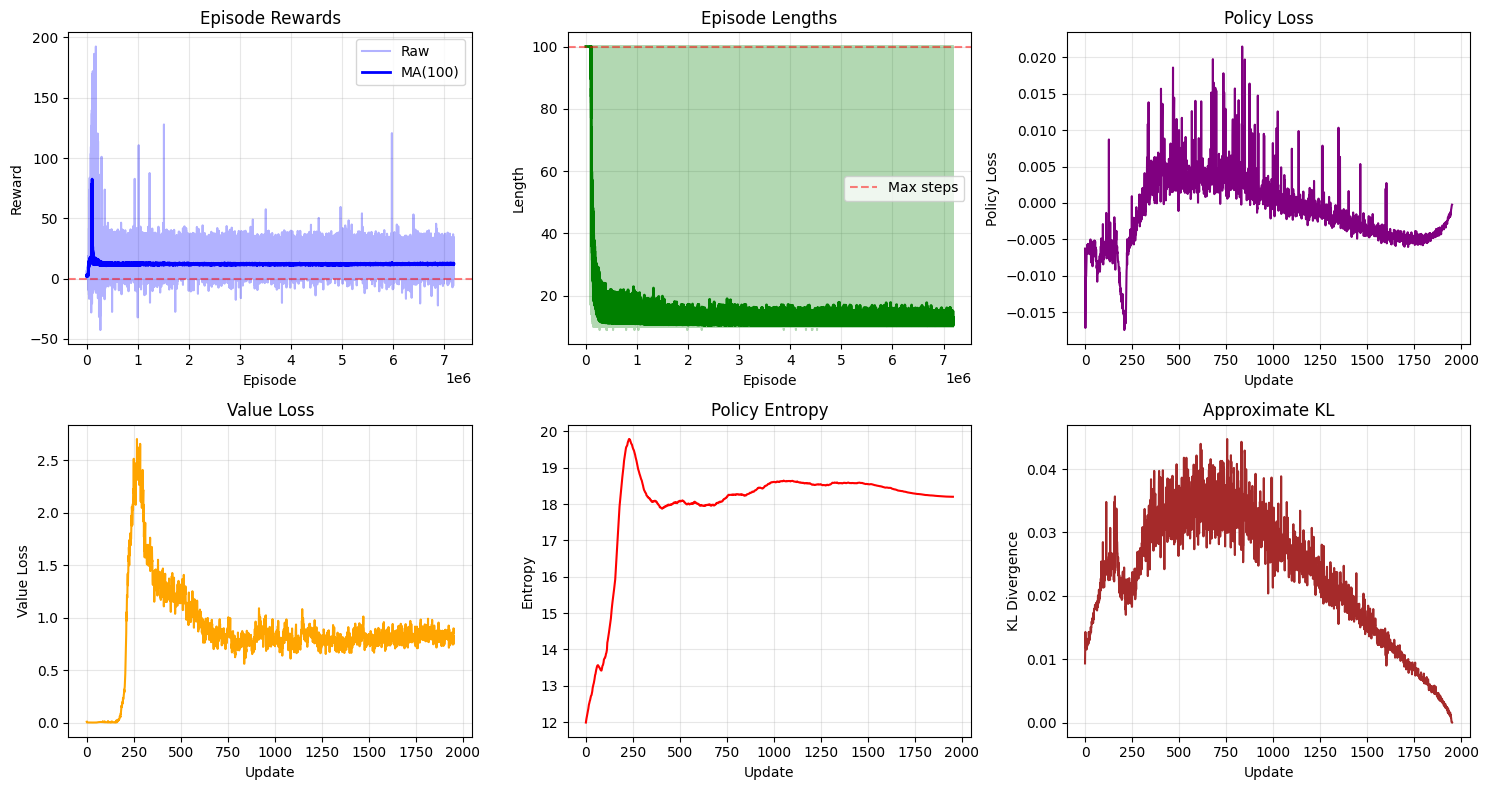

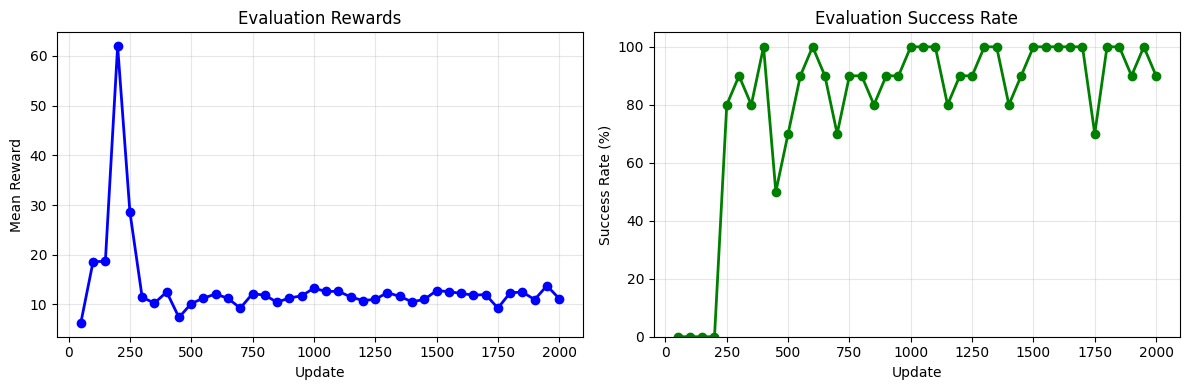

Training curves plotted!


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Episode rewards with rolling average
ax = axes[0, 0]
if len(history['episode_rewards']) > 0:
    rewards = np.array(history['episode_rewards'])
    ax.plot(rewards, alpha=0.3, color='blue', label='Raw')
    # Rolling average
    window = min(100, len(rewards) // 10) if len(rewards) > 100 else 10
    if len(rewards) > window:
        rolling = np.convolve(rewards, np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(rewards)), rolling, color='blue', linewidth=2, label=f'MA({window})')
    ax.axhline(y=0, color='r', linestyle='--', alpha=0.5)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Reward')
    ax.set_title('Episode Rewards')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Episode lengths
ax = axes[0, 1]
if len(history['episode_lengths']) > 0:
    lengths = np.array(history['episode_lengths'])
    ax.plot(lengths, alpha=0.3, color='green')
    window = min(100, len(lengths) // 10) if len(lengths) > 100 else 10
    if len(lengths) > window:
        rolling = np.convolve(lengths, np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(lengths)), rolling, color='green', linewidth=2)
    ax.axhline(y=MAX_EPISODE_STEPS, color='r', linestyle='--', alpha=0.5, label='Max steps')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Length')
    ax.set_title('Episode Lengths')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Policy loss
ax = axes[0, 2]
ax.plot(history['policy_losses'], color='purple')
ax.set_xlabel('Update')
ax.set_ylabel('Policy Loss')
ax.set_title('Policy Loss')
ax.grid(True, alpha=0.3)

# Value loss
ax = axes[1, 0]
ax.plot(history['value_losses'], color='orange')
ax.set_xlabel('Update')
ax.set_ylabel('Value Loss')
ax.set_title('Value Loss')
ax.grid(True, alpha=0.3)

# Entropy
ax = axes[1, 1]
ax.plot(history['entropies'], color='red')
ax.set_xlabel('Update')
ax.set_ylabel('Entropy')
ax.set_title('Policy Entropy')
ax.grid(True, alpha=0.3)

# KL divergence
ax = axes[1, 2]
ax.plot(history['kls'], color='brown')
ax.set_xlabel('Update')
ax.set_ylabel('KL Divergence')
ax.set_title('Approximate KL')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./results_g1/training_curves.png", dpi=150)
plt.show()

# Plot evaluation rewards and success rate
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

eval_updates = [(i + 1) * history['eval_interval'] for i in range(len(history['eval_rewards']))]

ax1.plot(eval_updates, history['eval_rewards'], marker='o', color='blue', linewidth=2)
ax1.set_xlabel('Update')
ax1.set_ylabel('Mean Reward')
ax1.set_title('Evaluation Rewards')
ax1.grid(True, alpha=0.3)

ax2.plot(eval_updates, [s * 100 for s in history['eval_success_rates']], marker='o', color='green', linewidth=2)
ax2.set_xlabel('Update')
ax2.set_ylabel('Success Rate (%)')
ax2.set_title('Evaluation Success Rate')
ax2.set_ylim([0, 105])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./results_g1/evaluation_curves.png", dpi=150)
plt.show()

print("Training curves plotted!")

## Part 9: Evaluation and Video

Load the best model and evaluate on 20 episodes using deterministic policy (action mean).
Report success rate and mean reward, record and show video of best episode.

In [12]:
# Part 9: Evaluation and Video
# Imports needed if running this cell independently
import torch
import torch.nn as nn
import gymnasium as gym
import numpy as np
import mediapy as media
from typing import Tuple, List, Optional, Any
from mani_skill.utils.wrappers.gymnasium import CPUGymWrapper

# Make sure device is defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ActorCritic network definition (copied from Part 3)
class ActorCritic(nn.Module):
    def __init__(self, obs_dim: int, action_dim: int):
        super().__init__()

        # Separate critic network: obs -> 256 -> 256 -> 256 -> 1
        self.critic = nn.Sequential(
            nn.Linear(obs_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, 1),
        )

        # Separate actor mean network: obs -> 256 -> 256 -> 256 -> action_dim
        self.actor_mean = nn.Sequential(
            nn.Linear(obs_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, action_dim),
        )

        # Learnable log standard deviation
        self.actor_logstd = nn.Parameter(torch.ones(action_dim) * -0.5)

        # Orthogonal initialization for critic hidden layers: gain sqrt(2)
        for module in self.critic:
            if isinstance(module, nn.Linear):
                nn.init.orthogonal_(module.weight, gain=np.sqrt(2))
                nn.init.constant_(module.bias, 0)
        # Critic output: gain 1.0
        nn.init.orthogonal_(self.critic[-1].weight, gain=1.0)
        nn.init.constant_(self.critic[-1].bias, 0)

        # Orthogonal initialization for actor hidden layers: gain sqrt(2)
        for module in self.actor_mean:
            if isinstance(module, nn.Linear):
                nn.init.orthogonal_(module.weight, gain=np.sqrt(2))
                nn.init.constant_(module.bias, 0)
        # Actor output: gain 0.01 * sqrt(2)
        nn.init.orthogonal_(self.actor_mean[-1].weight, gain=0.01 * np.sqrt(2))
        nn.init.constant_(self.actor_mean[-1].bias, 0)

    def get_action_and_value(self, obs: torch.Tensor, action: Optional[torch.Tensor] = None
                            ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        action_mean = self.actor_mean(obs)
        clamped_logstd = torch.clamp(self.actor_logstd, min=-2.0, max=0.5)
        std = torch.exp(clamped_logstd)
        dist = torch.distributions.Normal(action_mean, std)
        if action is None:
            action = dist.sample()
        log_prob = dist.log_prob(action).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1)
        value = self.critic(obs).squeeze(-1)
        return action, log_prob, entropy, value

    def get_value(self, obs: torch.Tensor) -> torch.Tensor:
        return self.critic(obs).squeeze(-1)

    def get_action_mean(self, obs: torch.Tensor) -> torch.Tensor:
        return self.actor_mean(obs)


# Wrapper classes (copied from Part 6)
class RightArmOnlyWrapper(gym.ActionWrapper):
    """Maps 13D policy actions to 25D env actions, zeroing left arm."""
    ACTIVE = [0, 2, 4, 6, 8, 10, 14, 15, 16, 20, 21, 22, 24]

    def __init__(self, env):
        super().__init__(env)
        low = env.action_space.low[..., self.ACTIVE]
        high = env.action_space.high[..., self.ACTIVE]
        self.action_space = gym.spaces.Box(low=low, high=high, dtype=np.float32)
        self._full_dim = env.action_space.shape[-1]

    def action(self, act):
        if isinstance(act, torch.Tensor):
            full = torch.zeros((*act.shape[:-1], self._full_dim), dtype=act.dtype, device=act.device)
        else:
            full = np.zeros((*act.shape[:-1], self._full_dim), dtype=np.float32)
        full[..., self.ACTIVE] = act
        return full


class CurriculumReleaseWrapper(gym.Wrapper):
    """Curriculum-based release incentive that activates after grasping is learned."""
    def __init__(self, env, eval_mode=False):
        super().__init__(env)
        self._reward_ema = 0.0
        self._total_steps = 0
        self._eval_mode = eval_mode
        self._hold_timer = None
        self._hold_threshold = 15
        self._hold_penalty_max = 0.2
        self._hold_ramp_steps = 10

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self._total_steps += 1
        alpha = 0.001
        self._reward_ema = (1 - alpha) * self._reward_ema + alpha * reward.mean().item()
        if self._eval_mode:
            release_weight = 1.0
        else:
            release_weight = max(0.0, min(1.0, (self._reward_ema - 0.03) / 0.05))

        if release_weight > 0.01:
            base_env = self.env.unwrapped
            apple_pos = base_env.apple.pose.p
            bowl_pos = base_env.bowl.pose.p
            tcp_pos = base_env.agent.right_tcp.pose.p
            finger_qpos = base_env.agent.robot.qpos[:, base_env.agent.right_finger_joint_indexes]

            goal_above_bowl = bowl_pos.clone()
            goal_above_bowl[:, 2] += 0.15
            obj_to_goal_dist = torch.linalg.norm(goal_above_bowl - apple_pos, axis=1)
            is_grasped = info["is_grasped"].float()
            not_grasped = 1.0 - is_grasped

            if self._hold_timer is None:
                self._hold_timer = torch.zeros(reward.shape[0], device=reward.device)

            holding_near_goal = (is_grasped > 0.5) & (obj_to_goal_dist < 0.10)
            self._hold_timer = torch.where(
                holding_near_goal,
                self._hold_timer + 1.0,
                torch.zeros_like(self._hold_timer)
            )
            done = terminated | truncated
            self._hold_timer = self._hold_timer * (~done).float()

            excess = torch.clamp(self._hold_timer - self._hold_threshold, min=0.0)
            hold_penalty = -self._hold_penalty_max * torch.clamp(
                excess / self._hold_ramp_steps, max=1.0
            )

            finger_openness = 1.0 - torch.tanh(torch.mean(torch.abs(finger_qpos), dim=1))
            close_to_goal = (obj_to_goal_dist < 0.08).float()
            release_bonus = close_to_goal * finger_openness * 0.3

            apple_to_bowl_dist = torch.linalg.norm(bowl_pos - apple_pos, axis=1)
            apple_near_bowl = torch.clamp(1.0 - apple_to_bowl_dist / 0.10, min=0.0)
            post_release_bonus = not_grasped * apple_near_bowl * 0.5

            hand_above = torch.clamp(
                (tcp_pos[:, 2] - bowl_pos[:, 2] - 0.125) / 0.1, min=0.0, max=1.0
            )
            retreat_bonus = not_grasped * apple_near_bowl * hand_above * 0.3

            bonus = release_weight * (release_bonus + post_release_bonus + retreat_bonus + hold_penalty)
            reward = reward + bonus

        return obs, reward, terminated, truncated, info


def flatten_obs(obs):
    """Helper to flatten ManiSkill3 observations (dict or tensor) to tensor."""
    if isinstance(obs, dict):
        if 'obs' in obs:
            obs_tensor = obs['obs']
            if isinstance(obs_tensor, torch.Tensor):
                return obs_tensor.float()
            else:
                return torch.from_numpy(obs_tensor).float()
        obs_parts = []
        for key in sorted(obs.keys()):
            val = obs[key]
            if isinstance(val, torch.Tensor):
                if val.dim() > 1:
                    obs_parts.append(val.reshape(val.shape[0], -1))
                else:
                    obs_parts.append(val.unsqueeze(-1) if val.dim() == 0 else val)
            elif isinstance(val, np.ndarray):
                tensor_val = torch.from_numpy(val).float()
                if tensor_val.dim() > 1:
                    obs_parts.append(tensor_val.reshape(tensor_val.shape[0], -1))
                else:
                    obs_parts.append(tensor_val.unsqueeze(-1) if tensor_val.dim() == 0 else tensor_val)
        if len(obs_parts) == 0:
            raise ValueError("No valid observation tensors found in dict")
        return torch.cat(obs_parts, dim=-1)
    elif isinstance(obs, torch.Tensor):
        # Handle batched or single observations
        if obs.dim() == 0:
            return obs.float().unsqueeze(0)
        return obs.float()
    elif isinstance(obs, np.ndarray):
        return torch.from_numpy(obs.copy()).float()
    else:
        raise ValueError(f"Unsupported observation type: {type(obs)}")



def record_episode(agent: ActorCritic, max_steps: int = 100,
                   deterministic: bool = True, device: torch.device = None) -> Tuple[float, bool, list]:
    """Record a single episode and return reward, success, and frames."""
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    env = gym.make(
        'UnitreeG1PlaceAppleInBowl-v1',
        num_envs=1,
        obs_mode='state',
        render_mode='rgb_array',
        reward_mode='normalized_dense'
    )
    env = RightArmOnlyWrapper(env)
    env = CurriculumReleaseWrapper(env, eval_mode=True)
    env = CPUGymWrapper(env)

    obs, _ = env.reset()
    frames = []
    episode_reward = 0
    done = False
    step_count = 0
    success = False
    
    while not done and step_count < max_steps:
        frame = env.render()
        frames.append(frame)
        
        obs_tensor = flatten_obs(obs).unsqueeze(0).to(device)
        
        with torch.no_grad():
            if deterministic:
                action = agent.get_action_mean(obs_tensor)
            else:
                action, _, _, _ = agent.get_action_and_value(obs_tensor)
        
        action_np = action.cpu().numpy()[0]
        obs, reward, terminated, truncated, info = env.step(action_np)
        episode_reward += reward
        step_count += 1
        done = terminated or truncated
        
        if 'success' in info and info['success']:
            success = True
    
    frames.append(env.render())
    env.close()
    return episode_reward, success, frames


# Load best model
print("Loading best model...")
checkpoint = torch.load("./results_g1/best_model.pt", map_location=device)

# Create dummy env WITH RightArmOnlyWrapper to get correct dimensions
temp_env = gym.make('UnitreeG1PlaceAppleInBowl-v1', num_envs=1, obs_mode='state')
temp_env = RightArmOnlyWrapper(temp_env)
obs_sample, _ = temp_env.reset()

if isinstance(obs_sample, dict):
    if 'obs' in obs_sample:
        obs_val = obs_sample['obs']
        if isinstance(obs_val, torch.Tensor):
            obs_tensor_sample = obs_val.float().flatten()
        else:
            obs_tensor_sample = torch.from_numpy(obs_val).float().flatten()
    else:
        obs_parts = []
        for key in sorted(obs_sample.keys()):
            val = obs_sample[key]
            if isinstance(val, torch.Tensor):
                obs_parts.append(val.float().flatten())
            elif isinstance(val, np.ndarray):
                obs_parts.append(torch.from_numpy(val).float().flatten())
        obs_tensor_sample = torch.cat(obs_parts)
elif isinstance(obs_sample, torch.Tensor):
    obs_tensor_sample = obs_sample.float().flatten()
else:
    obs_tensor_sample = torch.from_numpy(obs_sample).float().flatten()

obs_dim = obs_tensor_sample.shape[-1]
action_dim = temp_env.action_space.shape[-1]
temp_env.close()

print(f"Creating agent with obs_dim={obs_dim}, action_dim={action_dim}")
eval_agent = ActorCritic(obs_dim, action_dim).to(device)
eval_agent.load_state_dict(checkpoint['agent'])
eval_agent.eval()

# Run evaluation episodes
print("\nRunning evaluation on 20 episodes...")
eval_rewards = []
eval_successes = []
best_reward = -float('inf')
best_frames = None

for i in range(20):
    reward, success, frames = record_episode(eval_agent, max_steps=100, deterministic=True, device=device)
    eval_rewards.append(reward)
    eval_successes.append(success)
    if reward > best_reward:
        best_reward = reward
        best_frames = frames
    print(f"Episode {i+1}: reward={reward:.2f}, success={success}")

mean_reward = np.mean(eval_rewards)
std_reward = np.std(eval_rewards)
success_rate = np.mean(eval_successes)

print(f"\n{'='*60}")
print(f"Evaluation Results (20 episodes):")
print(f"  Mean reward: {mean_reward:.2f} ± {std_reward:.2f}")
print(f"  Success rate: {success_rate:.1%}")
print(f"{'='*60}")

# Show video of best episode
if best_frames is not None and len(best_frames) > 0:
    print(f"\nShowing best episode (reward={best_reward:.2f})...")
    media.show_video(best_frames, fps=30)


Loading best model...


[2026-03-13 14:14:06.113] [SAPIEN] [warning] A PhysX CPU system is being created while PhysX GPU is enabled. You can safely ignore this message if it is intended. To use GPU PhysX, create a sapien.physx.PhysxGpuSystem explicitly and pass it to sapien.Scene constructor.


Creating agent with obs_dim=74, action_dim=13

Running evaluation on 20 episodes...


[2026-03-13 14:14:07.195] [SAPIEN] [warning] A PhysX CPU system is being created while PhysX GPU is enabled. You can safely ignore this message if it is intended. To use GPU PhysX, create a sapien.physx.PhysxGpuSystem explicitly and pass it to sapien.Scene constructor.


Episode 1: reward=25.65, success=False


...

[2026-03-13 14:14:41.876] [SAPIEN] [warning] A PhysX CPU system is being created while PhysX GPU is enabled. You can safely ignore this message if it is intended. To use GPU PhysX, create a sapien.physx.PhysxGpuSystem explicitly and pass it to sapien.Scene constructor.


Episode 19: reward=26.56, success=False


[2026-03-13 14:14:44.091] [SAPIEN] [warning] A PhysX CPU system is being created while PhysX GPU is enabled. You can safely ignore this message if it is intended. To use GPU PhysX, create a sapien.physx.PhysxGpuSystem explicitly and pass it to sapien.Scene constructor.


Episode 20: reward=7.39, success=False

Evaluation Results (20 episodes):
  Mean reward: 22.48 ± 12.80
  Success rate: 5.0%

Showing best episode (reward=43.16)...


This browser does not support the video tag.


## Part 10: Save Results

Save the final model, statistics, and training history for future use.

In [13]:
# Part 10: Save Results
# This cell handles both cases: after training or standalone after evaluation

print("=" * 60)
print("Saving Results")
print("=" * 60)

# Check if training history exists (from Part 7)
if 'history' in globals() and history is not None:
    # Save training history
    np.savez(
        "./results_g1/training_history.npz",
        episode_rewards=history['episode_rewards'],
        episode_lengths=history['episode_lengths'],
        policy_losses=history['policy_losses'],
        value_losses=history['value_losses'],
        entropies=history['entropies'],
        kls=history['kls'],
        eval_rewards=history['eval_rewards'],
        eval_success_rates=history['eval_success_rates'],
    )
    print("Training history saved: ./results_g1/training_history.npz")
    
    # Use training hyperparameters if available
    total_timesteps = globals().get('TOTAL_TIMESTEPS', 'N/A')
    num_envs = globals().get('NUM_ENVS', 'N/A')
else:
    print("No training history found (Part 7 not run). Skipping history save.")
    total_timesteps = 'N/A'
    num_envs = 'N/A'

# Check if evaluation results exist (from Part 9)
if 'mean_reward' in globals() and 'success_rate' in globals():
    eval_mean = mean_reward
    eval_std = globals().get('std_reward', 0)
    eval_success = success_rate
else:
    eval_mean = 'N/A'
    eval_std = 'N/A'
    eval_success = 'N/A'

# Print summary
print("\n" + "=" * 60)
print("Summary")
print("=" * 60)
print(f"Environment: UnitreeG1PlaceAppleInBowl-v1")
if total_timesteps != 'N/A':
    print(f"Total timesteps: {total_timesteps:,}")
if num_envs != 'N/A':
    print(f"Number of parallel envs: {num_envs}")
print(f"Network: Separate 256-256-256 actor/critic architecture")

if eval_mean != 'N/A':
    print(f"\nFinal Evaluation (20 episodes, deterministic policy):")
    print(f"  Mean reward: {eval_mean:.2f} ± {eval_std:.2f}")
    print(f"  Success rate: {eval_success:.1%}")

print(f"\nSaved files:")
print(f"  - ./results_g1/best_model.pt")
if 'history' in globals() and history is not None:
    print(f"  - ./results_g1/training_history.npz")
    print(f"  - ./results_g1/training_curves.png")
    print(f"  - ./results_g1/evaluation_curves.png")
    print(f"  - ./results_g1/initial_state.png")
    print(f"  - ./results_g1/random_policy_rewards.png")
print("=" * 60)
print("Done!")
print("=" * 60)


Saving Results
Training history saved: ./results_g1/training_history.npz

Summary
Environment: UnitreeG1PlaceAppleInBowl-v1
Total timesteps: 100,000,000
Number of parallel envs: 512
Network: Separate 256-256-256 actor/critic architecture

Final Evaluation (20 episodes, deterministic policy):
  Mean reward: 22.48 ± 12.80
  Success rate: 5.0%

Saved files:
  - ./results_g1/best_model.pt
  - ./results_g1/training_history.npz
  - ./results_g1/training_curves.png
  - ./results_g1/evaluation_curves.png
  - ./results_g1/initial_state.png
  - ./results_g1/random_policy_rewards.png
Done!
